# Data extraction
We have downloaded the dataset with demographic information for every one of the 8132 municipalities in Spain from the MITECO (Spanish Ministry for the Ecological Transition and the Demographic Challenge) website. We also have downloaded the electoral results for the july 2023 and november 2019 general elections in Spain from the Spanish Ministry for the Interior, which are in a Excel format.

The implementation of most of the funcions for data extraction are in the `src/data_extraction.py` file. 

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

from src import data_extraction as de

## `load_miteco` Function

The `load_miteco` function extracts the demographic data from the MITECO dataset and merges it in a GeoDataFrame with the geographical data of the municipalities in Spain. We have the following data:

### Sapatial Variables
- `geometry`: Geometrical shape of the municipality (polygon)
- `latitude`: Latitude of the centroid of the municipality
- `longitude`: Longitude of the centroid of the municipality

### Geographical Identifiers
- `ccaa`: Autonomous community where the municipality is located
- `cod_ccaa`: Code of the autonomous community
- `cod_nut1`: Eurostats NUTS1 code (groups of autonomous communities)
- `cod_nut2`: Eurostats NUTS2 code (autonomous communities)
- `cod_nut3`: Eurostats NUTS3 code (provinces)
- `cod_prov`: Province code
- `codmun_ine`: Code of the municipality from the INE (Instituto Nacional de Estadística)
- `natcode`: National code of the municipality from the IGE (Instituto Geográfico Español)
- `nombre`: Name of the municipality
- `provincia`: Province where the municipality is located

### Demographic Variables
- `afi_1000`: Number of people affiliated to social security per 1000 inhabitants
- `dens_pob`: Population density (inhabitants per km²)
- `edad_media`: Median age of the population
- `pob_14`: Population in 2014
- `pob_14_23`: Variation in population between 2014 and 2023
- `pob_23`: Population in 2023
- `pob_esup16`: Share or count of the population older than 16 with higher education (university studies or equivalent)
- `pob_npum`: Share of the population living in the municipality in which they were born
- `porc_pob65`: Percentage of the population aged 65 years or older
- `porc_pob_e`: Percentage of foreign population living in the municipality
- `paro_1000`: Number of unemployed people per 1000 inhabitants
- `rat_mascul`: Masculinity ratio (defined as the number of men per 100 women)
- `rta_nt_med`: Mean Net Income (Renta Neta Media) of the municipality

In [2]:
gdf_miteco = de.load_miteco()
print(gdf_miteco.columns)
gdf_miteco

c:\Users\rodri\Mis archivos\Académico\Universidad\UCM\5º Mat-Inf\TFG Informática\tfg_electoral_analysis_spain_2023\src\data_extraction.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_miteco['latitude'] = gdf_miteco.geometry.centroid.y
c:\Users\rodri\Mis archivos\Académico\Universidad\UCM\5º Mat-Inf\TFG Informática\tfg_electoral_analysis_spain_2023\src\data_extraction.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_miteco['longitude'] = gdf_miteco.geometry.centroid.x


Index(['objectid', 'natcode', 'nombre', 'cod_nut1', 'cod_nut2', 'cod_nut3',
       'codmun_ine', 'ccaa', 'cod_ccaa', 'cod_pro', 'provincia', 'pob_npmun',
       'geometry', 'pob_23', 'dens_pob', 'edad_media', 'afi_1000', 'paro_1000',
       'porc_pob65', 'pob_esup16', 'porc_pob_e', 'rat_mascul', 'rta_nt_med',
       'pob_14', 'pob_14_23', 'latitude', 'longitude'],
      dtype='str')


,objectid,natcode,nombre,cod_nut1,cod_nut2,cod_nut3,codmun_ine,ccaa,cod_ccaa,cod_pro,...,paro_1000,porc_pob65,pob_esup16,porc_pob_e,rat_mascul,rta_nt_med,pob_14,pob_14_23,latitude,longitude
0,7732,34160101001,Alegría-Dulantzi,ES2,ES21,ES211,01001,País Vasco-Euskadi,16,01,...,78.298695,12.162162,42.332066,10.472973,107.172702,36393,2925,1.709402,42.829133,-2.511082
1,7733,34160101002,Amurrio,ES2,ES21,ES211,01002,País Vasco-Euskadi,16,01,...,108.861898,22.847972,38.223140,6.818403,99.131106,36362,10239,0.722727,43.025656,-2.971893
2,7737,34160101003,Aramaio,ES2,ES21,ES211,01003,País Vasco-Euskadi,16,01,...,4.206099,23.899371,49.760766,2.585604,108.124077,48487,1478,-4.668471,43.045985,-2.593614
3,7738,34160101004,Artziniega,ES2,ES21,ES211,01004,País Vasco-Euskadi,16,01,...,70.434070,18.784530,41.282565,5.414365,96.145610,33088,1818,0.770077,43.129709,-3.141468
4,7734,34160101006,Armiñón,ES2,ES21,ES211,01006,País Vasco-Euskadi,16,01,...,75.581395,14.468085,37.878788,5.106383,107.142857,32914,250,-7.200000,42.714114,-2.873388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,1737,34025050901,Biel,ES2,ES24,ES243,50901,Aragón,02,50,...,53.571429,37.058824,29.090909,14.705882,160.937500,28950,157,6.369427,42.369125,-0.912651
8127,1733,34025050902,Marracos,ES2,ES24,ES243,50902,Aragón,02,50,...,0.000000,35.164835,42.857143,0.000000,107.142857,28226,97,-10.309278,42.081172,-0.782404
8128,1734,34025050903,Villamayor de Gállego,ES2,ES24,ES243,50903,Aragón,02,50,...,49.670552,22.072869,31.265207,5.199859,103.118356,37009,2820,1.631206,41.693144,-0.739623
8129,8130,34185151001,Ceuta,ES6,ES63,ES630,51001,Ciudad Autónoma de Ceuta,18,51,...,170.032944,12.502857,24.343156,5.907335,101.820391,39330,84963,-2.264515,35.893598,-5.342890


In [3]:
# Drop geometry (keep only tabular data) and Save to Excel
gdf_miteco.drop(columns='geometry').to_excel(f'01_data_miteco.xlsx', index=False)

## `load_infoelectoral` Function

The `load_infoelectoral` function extracts the electoral data from the Infoelectoral .xlsx files for the july 2023 and november 2019 general elections in Spain. The data is extracted for the following parties: PP, PSOE, VOX, SUMAR. The function returns a DataFrame containing the combined data from all Infoelectoral .xlsx files. The DataFrame has the following columns:

- `codmun_ine`: Code of the municipality from the INE (Instituto Nacional de Estadística)
- `Votos válidos_2023`: Number of valid votes in the 2023 general election
- `PP_2023`: % of votes for the PP party in the 2023 general election
- `PSOE_2023`: % of votes for the PSOE party in the 2023 general election
- `VOX_2023`: % of votes for the VOX party in the 2023 general election
- `SUMAR_2023`: % of votes for the SUMAR party in the 2023 general election
- `Votos válidos_2019`: Number of valid votes in the 2019 general election
- `PP_2019`: % of votes for the PP party in the 2019 general election
- `PSOE_2019`: % of votes for the PSOE party in the 2019 general election
- `VOX_2019`: % of votes for the VOX party in the 2019 general election
- `SUMAR_2019`: % of votes for the SUMAR party in the 2019 general election

*Note:* SUMAR is a coalition of left-wing parties that was formed for the 2023 general election, so for the 2019 general election, the % of votes for SUMAR is calculated as the sum of the % of votes for the parties that form the SUMAR coalition (Podemos, Izquierda Unida, Más País, Equo, Compromís, etc.).

*Note:* In the province of Navarra, PP did not present candidacies in the 2019. Instead, the right-wing coalition Navarra Suma (NA+) (which included mainly PP and UPN) presented candidacies. On the other hand, in the 2023 general election, PP and UPN presented candidacies separately. As PP and UPN are sociologically very similar parties and UPN is only present in Navarra, we have considered the votes for UPN as votes for PP in the province of Navarra for both the 2019 and 2023 general elections. Therefore, in the province of Navarra, the % of votes for PP in 2023 is calculated as the sum of the % of votes for PP and UPN, and the % of votes for PP in 2019 is calculated as the % of votes for the Navarra Suma coalition in the 2019 general election.

*Note:* In 2023, Vox did not present candidacies in the Tenerife province. Therefore, the % of votes for Vox in the Tenerife province in 2023 is set to 0.

In [4]:
df_infoelectoral = de.load_infoelectoral()
print(df_infoelectoral.columns)
df_infoelectoral

Index(['codmun_ine', 'Votos válidos_2023', 'PSOE_2023', 'VOX_2023',
       'SUMAR_2023', 'PP_2023', 'Votos válidos_2019', 'PSOE_2019', 'VOX_2019',
       'PP_2019', 'SUMAR_2019'],
      dtype='str')


,codmun_ine,Votos válidos_2023,PSOE_2023,VOX_2023,SUMAR_2023,PP_2023,Votos válidos_2019,PSOE_2019,VOX_2019,PP_2019,SUMAR_2019
0,01001,1348,27.299703,4.821958,12.462908,10.459941,1372,20.699708,3.935860,8.309038,18.148688
1,01002,5610,22.994652,2.352941,10.213904,6.880570,5786,16.073280,2.661597,5.841687,14.967162
2,01003,731,7.523940,0.683995,9.302326,0.273598,837,3.106332,0.597372,0.358423,9.318996
3,01004,992,19.758065,3.326613,11.088710,10.383065,945,11.428571,3.492063,8.888889,15.555556
4,01006,134,20.895522,11.194030,14.179104,23.134328,122,16.393443,14.754098,17.213115,22.950820
...,...,...,...,...,...,...,...,...,...,...,...
8126,50901,122,29.508197,15.573770,13.934426,37.704918,96,34.375000,21.875000,18.750000,15.625000
8127,50902,68,29.411765,13.235294,0.000000,54.411765,62,24.193548,16.129032,46.774194,6.451613
8128,50903,1676,25.954654,19.749403,18.556086,31.801909,1670,25.928144,20.299401,19.341317,23.113772
8129,51001,33233,33.999338,23.296121,2.443354,38.777721,33265,31.279122,35.274312,22.266647,3.868931


## `compute_vote_differences` Function
The `compute_vote_differences` function computes the differences in the % of votes for each party between the 2023 and 2019 general elections. The function takes as input the DataFrame returned by the `load_infoelectoral` and adds new columns to the DataFrame with the differences in the % of votes for each party between the 2023 and 2019 general elections. The new columns are named as follows:
- `PP_diff_2023_2019`: Difference in the % of votes for the PP party between the 2023 and 2019 general elections
- `PSOE_diff_2023_2019`: Difference in the % of votes for the PSOE party between the 2023 and 2019 general elections
- `VOX_diff_2023_2019`: Difference in the % of votes for the VOX party between the 2023 and 2019 general elections
- `SUMAR_diff_2023_2019`: Difference in the % of votes for the SUMAR party between the 2023 and 2019 general elections

In [5]:
parties = ['PP', 'PSOE', 'VOX', 'SUMAR']
df_infoelectoral = de.compute_vote_differences(df_infoelectoral, parties, '2019', '2023')
print(df_infoelectoral.columns)
df_infoelectoral

Index(['codmun_ine', 'Votos válidos_2023', 'PSOE_2023', 'VOX_2023',
       'SUMAR_2023', 'PP_2023', 'Votos válidos_2019', 'PSOE_2019', 'VOX_2019',
       'PP_2019', 'SUMAR_2019', 'PP_diff_2023_2019', 'PSOE_diff_2023_2019',
       'VOX_diff_2023_2019', 'SUMAR_diff_2023_2019'],
      dtype='str')


,codmun_ine,Votos válidos_2023,PSOE_2023,VOX_2023,SUMAR_2023,PP_2023,Votos válidos_2019,PSOE_2019,VOX_2019,PP_2019,SUMAR_2019,PP_diff_2023_2019,PSOE_diff_2023_2019,VOX_diff_2023_2019,SUMAR_diff_2023_2019
0,01001,1348,27.299703,4.821958,12.462908,10.459941,1372,20.699708,3.935860,8.309038,18.148688,2.150903,6.599995,0.886098,-5.685780
1,01002,5610,22.994652,2.352941,10.213904,6.880570,5786,16.073280,2.661597,5.841687,14.967162,1.038884,6.921372,-0.308656,-4.753258
2,01003,731,7.523940,0.683995,9.302326,0.273598,837,3.106332,0.597372,0.358423,9.318996,-0.084825,4.417608,0.086623,-0.016671
3,01004,992,19.758065,3.326613,11.088710,10.383065,945,11.428571,3.492063,8.888889,15.555556,1.494176,8.329493,-0.165451,-4.466846
4,01006,134,20.895522,11.194030,14.179104,23.134328,122,16.393443,14.754098,17.213115,22.950820,5.921214,4.502080,-3.560069,-8.771715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,50901,122,29.508197,15.573770,13.934426,37.704918,96,34.375000,21.875000,18.750000,15.625000,18.954918,-4.866803,-6.301230,-1.690574
8127,50902,68,29.411765,13.235294,0.000000,54.411765,62,24.193548,16.129032,46.774194,6.451613,7.637571,5.218216,-2.893738,-6.451613
8128,50903,1676,25.954654,19.749403,18.556086,31.801909,1670,25.928144,20.299401,19.341317,23.113772,12.460592,0.026510,-0.549998,-4.557687
8129,51001,33233,33.999338,23.296121,2.443354,38.777721,33265,31.279122,35.274312,22.266647,3.868931,16.511074,2.720216,-11.978191,-1.425577


In [6]:
df_infoelectoral.to_excel(f'01_data_infoelectoral.xlsx', index=False)

## `extract_data` Function

The `extract_data` function combines the demographic data from the MITECO dataset and the electoral data from the Infoelectoral .xlsx files. It merges the two datasets based on the municipality codes, computes the vote differences, and returns a single GeoDataFrame that contains both demographic and electoral information for each municipality in Spain.

In [7]:
gdf = de.extract_data()
print(gdf.columns)
gdf

c:\Users\rodri\Mis archivos\Académico\Universidad\UCM\5º Mat-Inf\TFG Informática\tfg_electoral_analysis_spain_2023\src\data_extraction.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_miteco['latitude'] = gdf_miteco.geometry.centroid.y
c:\Users\rodri\Mis archivos\Académico\Universidad\UCM\5º Mat-Inf\TFG Informática\tfg_electoral_analysis_spain_2023\src\data_extraction.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_miteco['longitude'] = gdf_miteco.geometry.centroid.x


MITECO data loaded with 8131 records.
Infoelectoral data loaded with 8131 records.
Data combined with 8131 records after merging.
Vote differences computed for parties: PP, PSOE, VOX, SUMAR
Index(['objectid', 'natcode', 'nombre', 'cod_nut1', 'cod_nut2', 'cod_nut3',
       'codmun_ine', 'ccaa', 'cod_ccaa', 'cod_pro', 'provincia', 'pob_npmun',
       'geometry', 'pob_23', 'dens_pob', 'edad_media', 'afi_1000', 'paro_1000',
       'porc_pob65', 'pob_esup16', 'porc_pob_e', 'rat_mascul', 'rta_nt_med',
       'pob_14', 'pob_14_23', 'latitude', 'longitude', 'Votos válidos_2023',
       'PSOE_2023', 'VOX_2023', 'SUMAR_2023', 'PP_2023', 'Votos válidos_2019',
       'PSOE_2019', 'VOX_2019', 'PP_2019', 'SUMAR_2019', 'PP_diff_2023_2019',
       'PSOE_diff_2023_2019', 'VOX_diff_2023_2019', 'SUMAR_diff_2023_2019'],
      dtype='str')


,objectid,natcode,nombre,cod_nut1,cod_nut2,cod_nut3,codmun_ine,ccaa,cod_ccaa,cod_pro,...,PP_2023,Votos válidos_2019,PSOE_2019,VOX_2019,PP_2019,SUMAR_2019,PP_diff_2023_2019,PSOE_diff_2023_2019,VOX_diff_2023_2019,SUMAR_diff_2023_2019
0,7732,34160101001,Alegría-Dulantzi,ES2,ES21,ES211,01001,País Vasco-Euskadi,16,01,...,10.459941,1372,20.699708,3.935860,8.309038,18.148688,2.150903,6.599995,0.886098,-5.685780
1,7733,34160101002,Amurrio,ES2,ES21,ES211,01002,País Vasco-Euskadi,16,01,...,6.880570,5786,16.073280,2.661597,5.841687,14.967162,1.038884,6.921372,-0.308656,-4.753258
2,7737,34160101003,Aramaio,ES2,ES21,ES211,01003,País Vasco-Euskadi,16,01,...,0.273598,837,3.106332,0.597372,0.358423,9.318996,-0.084825,4.417608,0.086623,-0.016671
3,7738,34160101004,Artziniega,ES2,ES21,ES211,01004,País Vasco-Euskadi,16,01,...,10.383065,945,11.428571,3.492063,8.888889,15.555556,1.494176,8.329493,-0.165451,-4.466846
4,7734,34160101006,Armiñón,ES2,ES21,ES211,01006,País Vasco-Euskadi,16,01,...,23.134328,122,16.393443,14.754098,17.213115,22.950820,5.921214,4.502080,-3.560069,-8.771715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,1737,34025050901,Biel,ES2,ES24,ES243,50901,Aragón,02,50,...,37.704918,96,34.375000,21.875000,18.750000,15.625000,18.954918,-4.866803,-6.301230,-1.690574
8127,1733,34025050902,Marracos,ES2,ES24,ES243,50902,Aragón,02,50,...,54.411765,62,24.193548,16.129032,46.774194,6.451613,7.637571,5.218216,-2.893738,-6.451613
8128,1734,34025050903,Villamayor de Gállego,ES2,ES24,ES243,50903,Aragón,02,50,...,31.801909,1670,25.928144,20.299401,19.341317,23.113772,12.460592,0.026510,-0.549998,-4.557687
8129,8130,34185151001,Ceuta,ES6,ES63,ES630,51001,Ciudad Autónoma de Ceuta,18,51,...,38.777721,33265,31.279122,35.274312,22.266647,3.868931,16.511074,2.720216,-11.978191,-1.425577


In [8]:
gdf.drop(columns='geometry').to_excel(f'01_data_combined.xlsx', index=False)

In [9]:
#Sample 1000 rows to keep it fast
# Save the map as an HTML
m = gdf.explore()
m.save('01_map_output.html')
print("Map saved to 01_map_output.html - open it in your browser (Note: it is heavy, it will consume a lot of memory and may be slow to load)")

Map saved to 01_map_output.html - open it in your browser (Note: it is heavy, it will consume a lot of memory and may be slow to load)


<Axes: >

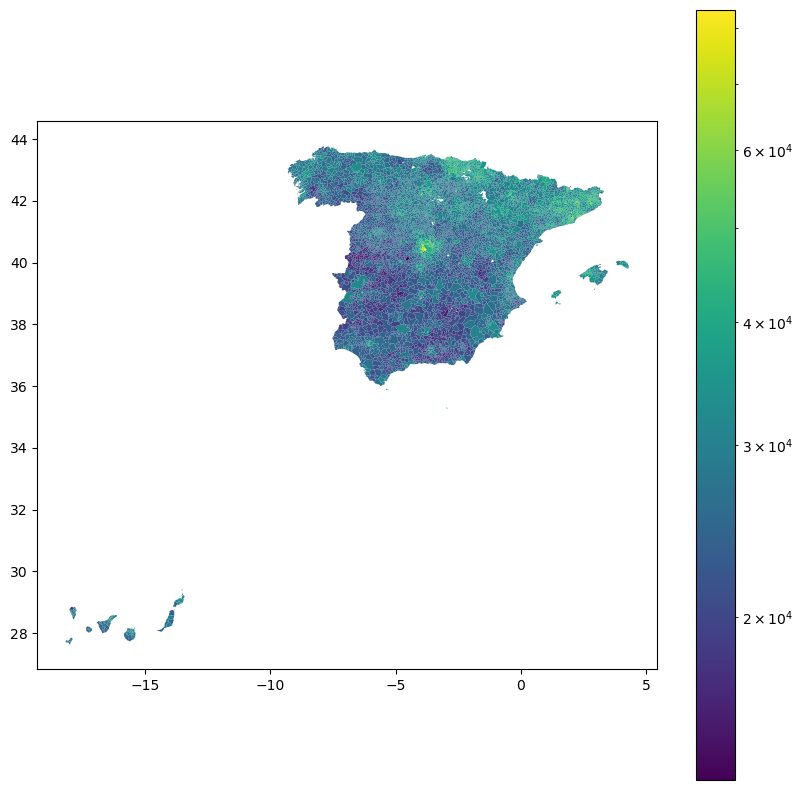

In [10]:
import matplotlib

# Log scale coloring
gdf.plot(column='rta_nt_med', legend=True, figsize=(10, 10), cmap='viridis', norm=matplotlib.colors.LogNorm())